Nomes:
Afonso Henrique C de Oliveira - RA: 235385  
Gabrielle Amaro Marchioli - RA: 236775  
Giulianno Giaciani Gonçalves - RA: 235484  
Kaique Vecchia Alves - RA: 235446
Kauan Victor Marques - RA: 235003
Nathalia Atamanchuk Baleeiro - RA: 235215
Patrick Vieira Léo - RA: 234868

In [5]:
%pip install numpy opencv-python matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Aula Lab. 8 - OpenCV

## Vizinhança, conexão e filtros

Nestes exercícios vamos aprender:

* Como usar filtro de limiarização: histograma para isolar similaridades
* Como preencher um elemento
* Como destacar a borda de um elemento
* Aplicação de filtro: Correlação
* Aplicação de filtro: Convolução
    * Filtro passa baixa
    * filtro passa alta

Começamos com o cabeçalho padrão:

In [6]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

E adição da pasta de exemplos (comente o código se não estiver usando em seu ambiente)

In [7]:
cv.samples.addSamplesDataSearchPath('data')

### Limiarização

Usaremos o arquivo smarties.png carregado em RGB em *smarties* (P.S.: apesar de ser png, esse arquivo não contém canal &alpha;, sendo BGR simples).

Podemos seprar objetos da imagem usando o brilho como característica, sabendo que a escala de brilho tem *correlação* direta com as cores RGB (a equação de conversão vista em experimentos anteriores).

Para isso vamos:

* Separe o canal de luminsidade em *smarties_l* (dica: GRAY)
* Calcule o histograma em *smarties_h*
* Faça o plot 2x1: esq. da imagem colorida, dir. do histograma
    * devido ao fundo branco, limite o eixo x para 200 e o eixo y para 2000


smarties.png não encontrado — criando imagem sintética para demonstração.


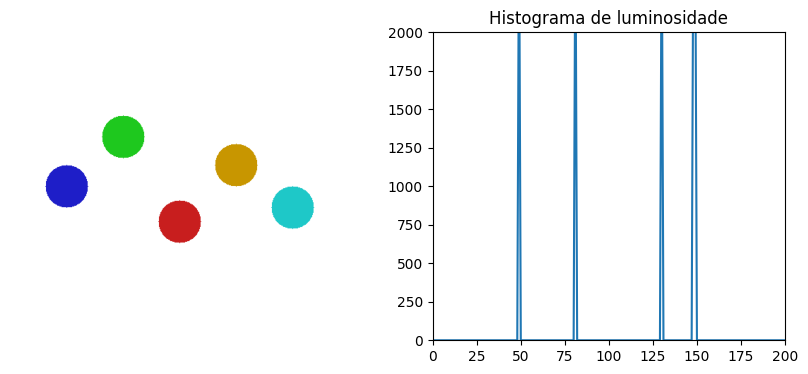

In [8]:
import os

def load_or_synth(name, synth_fn):
    try:
        f = cv.samples.findFile(name)
    except Exception:
        f = name
    if os.path.exists(f):
        img = cv.imread(f)
        if img is not None:
            return img
    print(f'{name} não encontrado — criando imagem sintética para demonstração.')
    return synth_fn()

def synth_smarties():
    img = np.full((300,500,3),255,dtype=np.uint8)
    colors = [(200,30,30),(30,200,30),(30,30,200),(0,150,200),(200,200,30)]
    centers = [(80,150),(160,80),(240,200),(320,120),(400,180)]
    for c,col in zip(centers,colors):
        cv.circle(img,c,30,col,-1)
    return img

smarties = load_or_synth('smarties.png', synth_smarties)
smarties_rgb = cv.cvtColor(smarties, cv.COLOR_BGR2RGB)
smarties_l = cv.cvtColor(smarties, cv.COLOR_BGR2GRAY)
smarties_h = cv.calcHist([smarties_l],[0],None,[256],[0,256]).ravel()
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(smarties_rgb)
plt.axis('off')
plt.subplot(1,2,2)
plt.plot(smarties_h)
plt.xlim(0,200)
plt.ylim(0,2000)
plt.title('Histograma de luminosidade')
plt.show()

Perceba que temos 2 picos bem distintos, usando *argmax* de Numpy:

* print a posição do o máximo entre 50 e 100
* print a posição do o máximo entre 150 e 200

In [9]:
# Encontrar picos no histograma usando argmax em intervalos
# assumindo smarties_h já calculado na célula anterior
p1 = np.argmax(smarties_h[50:100]) + 50
p2 = np.argmax(smarties_h[150:200]) + 150
print('max entre 50-100 ->', p1)
print('max entre 150-200 ->', p2)

max entre 50-100 -> 81
max entre 150-200 -> 150


Vamos limiarizar a imagem!

* construa dois arrays de zeros de 256 posições: *obj1_lut* e *obj2_lut*
* para cara um, coloque L<sub>max</sub> no pico e nos cinco valores em sua volta (pico &plusmn;5)
* use LUT para gerar as máscaras *obj1_msk* e *obj2_msk*
* plot 3x2
    * Linhas objetos
    * Colunas Imagem original, máscara, imagem com máscara aplicada

Responda com print:
* qual a cor do obj1?
* qual a cor do obj2?

cor do obj1 (RGB médio): (200, 30, 30)
cor do obj2 (RGB médio): (115, 175, 100)


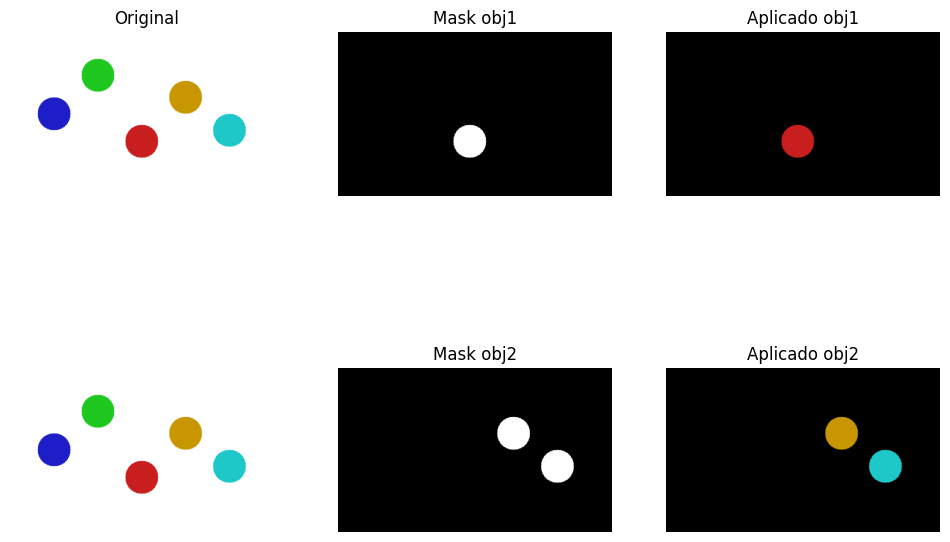

In [10]:
# Criar LUTs para dois objetos baseados nos picos detectados
obj1_lut = np.zeros(256, dtype=np.uint8)
obj2_lut = np.zeros(256, dtype=np.uint8)
# usar picos p1 e p2 computados anteriormente
L1 = p1
L2 = p2
rng = 5
obj1_lut[max(0,L1-rng):min(256,L1+rng+1)] = 255
obj2_lut[max(0,L2-rng):min(256,L2+rng+1)] = 255
obj1_msk = cv.LUT(smarties_l, obj1_lut)
obj2_msk = cv.LUT(smarties_l, obj2_lut)
# garantir máscara binária (0/255)
_, obj1_msk = cv.threshold(obj1_msk, 1, 255, cv.THRESH_BINARY)
_, obj2_msk = cv.threshold(obj2_msk, 1, 255, cv.THRESH_BINARY)
# aplicar máscara nas imagens coloridas
obj1_col = cv.bitwise_and(smarties, smarties, mask=obj1_msk)
obj2_col = cv.bitwise_and(smarties, smarties, mask=obj2_msk)
# cores médias (converter BGR->RGB para interpretação)
c1 = cv.mean(smarties_rgb, mask=obj1_msk)[:3]
c2 = cv.mean(smarties_rgb, mask=obj2_msk)[:3]
print('cor do obj1 (RGB médio):', tuple(map(int,c1)))
print('cor do obj2 (RGB médio):', tuple(map(int,c2)))
# Plot 3x2: cada linha um objeto (origem, máscara, aplicado)
fig, axs = plt.subplots(2,3, figsize=(12,8))
axs[0,0].imshow(smarties_rgb); axs[0,0].set_title('Original'); axs[0,0].axis('off')
axs[0,1].imshow(obj1_msk, cmap='gray'); axs[0,1].set_title('Mask obj1'); axs[0,1].axis('off')
axs[0,2].imshow(cv.cvtColor(obj1_col, cv.COLOR_BGR2RGB)); axs[0,2].set_title('Aplicado obj1'); axs[0,2].axis('off')
axs[1,0].imshow(smarties_rgb); axs[1,0].axis('off')
axs[1,1].imshow(obj2_msk, cmap='gray'); axs[1,1].set_title('Mask obj2'); axs[1,1].axis('off')
axs[1,2].imshow(cv.cvtColor(obj2_col, cv.COLOR_BGR2RGB)); axs[1,2].set_title('Aplicado obj2'); axs[1,2].axis('off')
plt.show()

#### Desafio 1

Usando o mesmo processo de limiarização tente isolar, da melhor forma possível, as bolas azuis.

Print:
* Os limites min. e max. de busca do pico
* O pico dentro do Limite
* Os valores de min. e max. do range da limiarização

Plot: imagem original, máscara, imagem com máscara aplicada

> Note que pelo brilho apenas, isolar objetos pelas cores não é um método muito eficaz para este caso.

limite min,max de busca: 10 110
pico dentro do limite: 49
range limiarização: 44 54


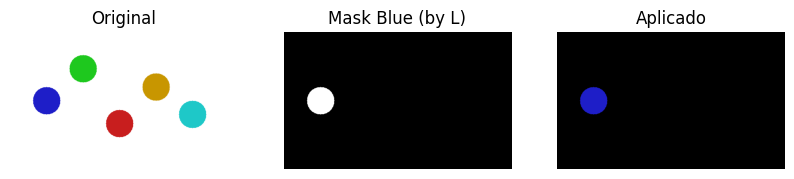

In [11]:
# Desafio 1: tentar isolar as bolas azuis usando brilho (tentativa)
# buscamos um pico em faixa típica de brilho para azuis (ajustável)
min_search, max_search = 10, 110
sub = smarties_h[min_search:max_search]
peak_rel = np.argmax(sub)
peak = peak_rel + min_search
th_min, th_max = max(0, peak-5), min(255, peak+5)
print('limite min,max de busca:', min_search, max_search)
print('pico dentro do limite:', peak)
print('range limiarização:', th_min, th_max)
lut = np.zeros(256, dtype=np.uint8)
lut[th_min:th_max+1] = 255
blue_msk = cv.LUT(smarties_l, lut)
_, blue_msk = cv.threshold(blue_msk,1,255,cv.THRESH_BINARY)
blue_col = cv.bitwise_and(smarties, smarties, mask=blue_msk)
plt.figure(figsize=(10,4))
plt.subplot(1,3,1); plt.imshow(smarties_rgb); plt.axis('off'); plt.title('Original')
plt.subplot(1,3,2); plt.imshow(blue_msk, cmap='gray'); plt.axis('off'); plt.title('Mask Blue (by L)')
plt.subplot(1,3,3); plt.imshow(cv.cvtColor(blue_col, cv.COLOR_BGR2RGB)); plt.axis('off'); plt.title('Aplicado')
plt.show()

### Preencher objetos e destacar bordas

> Nora: coordenadas dadas estão em (x,y)


#### Exercício, preencher com vizinhança 4
Vamos pegar um recorte da máscara do objeto 1, ROI[(70,230),(130,290)]

* Crie uma função (*fill4(msk, pt, color)*) que irá receber a máscara e percorrer cada pixel da imagem (não use flat nem gravel, as coordenadas x,y serão necessárias)
* Passe uma coordenada válida como ponto inical, **(27,5)** [cuidado, essa posição é relativa com a ROI]
* Passe uma cor para preencher, **[220, 20, 60]** (Crimson)
* Com o uso de duas pilhas
    * na pilha de trabalho, *wrk*, guarde a coordenada inicial
    * na pilha de objeto, *painted*, guarde as coordenadas que foram pintadas, ou seja, nosso objeto
* Crie uma imagem de destino **RGB** com as mesmas dimensões
* Use a vizinhança 4: (x-1,y),(x+1,y),(x,y-1),(x,y+1).
    * Uma pixel vizinho é conexo quando o valor em x,y é 1 o vizinho também é 1
* Algoritmo:
    * remova uma coordenada de trabalho, pinte o pixel no destino nessa coordenada, guarde a coordenada na pilha de objeto pintado
    * armazene as coordenadas vizinhas na pilha de trabalho a coordenada dos pixels vizinhos se:
        * a coordenada for válida
        * o valor do pixel na coordenada na máscara for 255 (ou 1.0, se estiver usando float)
        * a coordenada já não foi pintada (não está na pilha de objeto)
    * repita até a pilha estar vazia
* Plot a ROI e a imagem de retorno



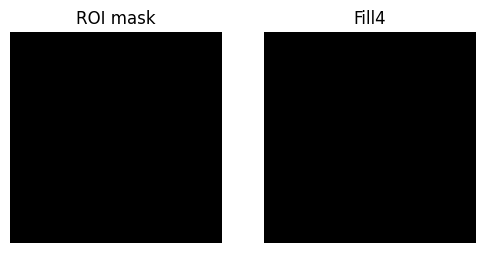

In [12]:
# Fill4: preencher objeto usando vizinhança-4
def fill4(msk, pt, color):
    h,w = msk.shape
    dst = np.zeros((h,w,3), dtype=np.uint8)
    visited = np.zeros_like(msk, dtype=bool)
    stack = [pt]
    while stack:
        x,y = stack.pop()
        if x<0 or y<0 or x>=w or y>=h:
            continue
        if visited[y,x]:
            continue
        if msk[y,x]==0:
            continue
        dst[y,x] = color
        visited[y,x] = True
        # vizinhança 4 (x-1,y),(x+1,y),(x,y-1),(x,y+1)
        for nx,ny in ((x-1,y),(x+1,y),(x,y-1),(x,y+1)):
            if 0<=nx<w and 0<=ny<h and not visited[ny,nx] and msk[ny,nx]>0:
                stack.append((nx,ny))
    return dst
# ROI conforme enunciado: (y1:y2, x1:x2)
y1,y2,x1,x2 = 70,130,230,290
roi_msk = obj1_msk[y1:y2, x1:x2].copy()
filled4 = fill4(roi_msk, (27,5), [220,20,60])
plt.figure(figsize=(6,4))
plt.subplot(1,2,1); plt.imshow(roi_msk, cmap='gray'); plt.title('ROI mask'); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(filled4); plt.title('Fill4'); plt.axis('off')
plt.show()

#### Exercício, preencher com vizinhança 8

Copie a função anterior, altere o nome para *fill8*.

Nosso algoritmo agora deverá considerar, além dos pontos anteriores, as diagonais: (x-1, y-1), (x-1, y+1), (x+1, y-1), (x+1, y+1)

Use o mesmo ROI e posição pixel inicial.

> Perceba que considerar as diagonais pode causar a agregação de pixeis indesejados

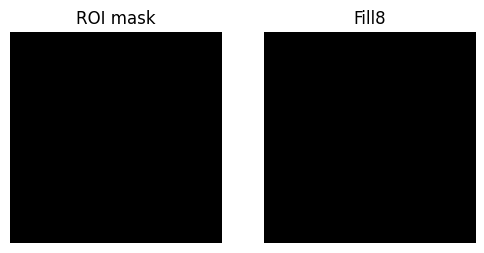

In [13]:
# Fill8: mesma ideia incluindo diagonais
def fill8(msk, pt, color):
    h,w = msk.shape
    dst = np.zeros((h,w,3), dtype=np.uint8)
    visited = np.zeros_like(msk, dtype=bool)
    stack = [pt]
    neigh = [(-1,0),(1,0),(0,-1),(0,1),(-1,-1),(-1,1),(1,-1),(1,1)]
    while stack:
        x,y = stack.pop()
        if x<0 or y<0 or x>=w or y>=h: continue
        if visited[y,x]: continue
        if msk[y,x]==0: continue
        dst[y,x] = color
        visited[y,x] = True
        for dx,dy in neigh:
            nx,ny = x+dx, y+dy
            if 0<=nx<w and 0<=ny<h and not visited[ny,nx] and msk[ny,nx]>0:
                stack.append((nx,ny))
    return dst
filled8 = fill8(roi_msk, (27,5), [220,20,60])
plt.figure(figsize=(6,4))
plt.subplot(1,2,1); plt.imshow(roi_msk, cmap='gray'); plt.title('ROI mask'); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(filled8); plt.title('Fill8'); plt.axis('off')
plt.show()

#### Exercício, pintar borda com vizinhança 4

Vamos continuar usando o mesmo recorte e posição inicial.

* Copie a função *fill4* anterior agora com novo nome *border4*
* Passe uma cor para borda, [100, 100, 100] (cinza)
* Altere o algoritmo de tal forma a acrescentar a regra:
    * antes de pintar o pixel no destino: um pixel na borda só pode ter até 3 vizinos na máscara (se tiver os 4 vizinhos, ele é um pixel de interior)
* Plot a ROI (esq.) e a adição (dir.) da imagem de contorno com a de preenchimento (use cv.add)

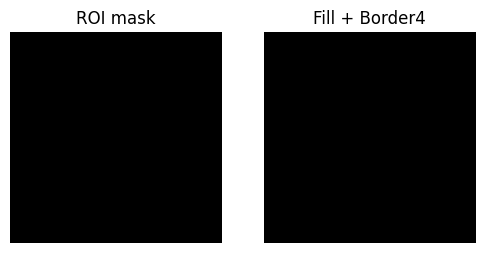

In [14]:
# Border4: pintar borda usando regra de até 3 vizinhos na máscara
def border4(msk, pt, color):
    h,w = msk.shape
    dst = np.zeros((h,w,3), dtype=np.uint8)
    visited = np.zeros_like(msk, dtype=bool)
    stack = [pt]
    while stack:
        x,y = stack.pop()
        if x<0 or y<0 or x>=w or y>=h: continue
        if visited[y,x]: continue
        if msk[y,x]==0: continue
        # contar vizinhos 4 na máscara
        cnt = 0
        for nx,ny in ((x-1,y),(x+1,y),(x,y-1),(x,y+1)):
            if 0<=nx<w and 0<=ny<h and msk[ny,nx]>0:
                cnt += 1
        if cnt <= 3:
            dst[y,x] = color
        visited[y,x] = True
        for nx,ny in ((x-1,y),(x+1,y),(x,y-1),(x,y+1)):
            if 0<=nx<w and 0<=ny<h and not visited[ny,nx] and msk[ny,nx]>0:
                stack.append((nx,ny))
    return dst
border4_img = border4(roi_msk, (27,5), [100,100,100])
combined4 = cv.add(fill4(roi_msk,(27,5),[220,20,60]), border4_img)
plt.figure(figsize=(6,4))
plt.subplot(1,2,1); plt.imshow(roi_msk, cmap='gray'); plt.title('ROI mask'); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(combined4); plt.title('Fill + Border4'); plt.axis('off')
plt.show()

#### Exercício, pintar borda com vizinhança 8

Vamos continuar usando o mesmo recorte e posição inicial.

* Copie a função *fill8* agora com nome *border8*
* Passe uma cor para borda, **[100, 100, 100]** (cinza)
* Altere o algoritmo de tal forma a acrescentar uma regra:
    * antes de pintar o pixel no destino: um pixel na borda só pode ter até 7 vizinos na máscara (se tiver os 8 vizinhos, ele é um pixel de interior)
* Plot a ROI (esq.) e a adição (dir.) da imagem de contorno com a de preenchimento (use cv.add)

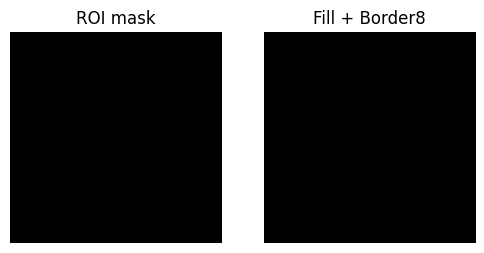

In [15]:
# Border8: pintar borda usando regra de até 7 vizinhos
def border8(msk, pt, color):
    h,w = msk.shape
    dst = np.zeros((h,w,3), dtype=np.uint8)
    visited = np.zeros_like(msk, dtype=bool)
    neigh = [(-1,0),(1,0),(0,-1),(0,1),(-1,-1),(-1,1),(1,-1),(1,1)]
    stack = [pt]
    while stack:
        x,y = stack.pop()
        if x<0 or y<0 or x>=w or y>=h: continue
        if visited[y,x]: continue
        if msk[y,x]==0: continue
        cnt = 0
        for dx,dy in neigh:
            nx,ny = x+dx, y+dy
            if 0<=nx<w and 0<=ny<h and msk[ny,nx]>0:
                cnt += 1
        if cnt <= 7:
            dst[y,x] = color
        visited[y,x] = True
        for dx,dy in neigh:
            nx,ny = x+dx, y+dy
            if 0<=nx<w and 0<=ny<h and not visited[ny,nx] and msk[ny,nx]>0:
                stack.append((nx,ny))
    return dst
border8_img = border8(roi_msk, (27,5), [100,100,100])
combined8 = cv.add(fill8(roi_msk,(27,5),[220,20,60]), border8_img)
plt.figure(figsize=(6,4))
plt.subplot(1,2,1); plt.imshow(roi_msk, cmap='gray'); plt.title('ROI mask'); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(combined8); plt.title('Fill + Border8'); plt.axis('off')
plt.show()

> **OBSERVE**
>
> Na vizinhança-4
> * para preencher objeto, pixeis avulsos na diagonal são removidos.
> * para preencher a borda do objeto pulou os pixels nas diagonais pois um pixel na diagonal tem 4 vizinhos.
>
> Na vizinhança-8
> * para preencher objeto, pixeis avulsos na diagonal são considerados.
> * para preencher a borda do objeto adicionaou os pixels nas diagonais.

### Aplicação de Filtro: Correlação

A correlação é uma forma de procurar um padrão. Verificar a similaridade entre um filtro e uma área de mesmo tamanho na imagem.

De forma geral temos:

1. Posiciona-se o centro do padrão de busca (máscara de busca ou filtro) com cada pixel da imagem.
1. Executa-se a multiplicação elemento por elemento entre filtro e imagem
1. Faz-se a somatória das multiplicações
1. O resultado é colocado na coordenada atual na imagem de destino

A etapa 2 (CCORR) pode ser substituida por outras fórmulas como: a diferença do quadrado (SQDIFF) ou a média corrida (CCOEFF)

> Nota: é recomendável trabalhar com a forma normalizada

#### Exercício

* Vamos carregar messi5.jpg RGB em *messi*
* Vamos trabalhar com o canal de Luminosidade, converta pra Grayscale em *messi_l*
* Vamor carregar o objeto que queremos procurar na imagem messi5_ball.jpg Grayscale em *ball*
* O OpenCV já possui uma função de correlção pronta [cv.matchTemplate(image, templ, method[, result[, mask]])](https://docs.opencv.org/4.x/df/dfb/group__imgproc__object.html#gga3a7850640f1fe1f58fe91a2d7583695dac5babb7dfda59544e3e31ea928f8cb16)
    * A correlação mais simples é a TM_CCORR que executa a multiplicação pixel-a-pixel e depois soma

Internamente a função fará o alinhamento do primeiro pixel do filtro com o primeiro pixel da imagem, nesse caso a imagem de saída é menor que a imagem de original
* W<sub>res</sub> = W<sub>img</sub> - W<sub>kernel</sub> + 1
* H<sub>res</sub> = H<sub>img</sub> - H<sub>kernel</sub> + 1

Para cada pixel no destino será atribuido um valor que expressa o quanto que aquela área na imagem de origem se parece (correlaciona) com o filtro.

Após Percorrer toda a área da imagem deve-se procurar o pixel de maior valor. O OpenCV possui a função [cv.minMaxLoc(src[, mask])-> minVal, maxVal, minLoc, maxLoc](https://docs.opencv.org/4.x/d2/de8/group__core__array.html#gab473bf2eb6d14ff97e89b355dac20707) que retorna os valores de Mínimo e Máximo assim como suas respsctivas localizações [x,y]

> **Nota**: na correlação SQDIFF, o valor mais próximo de 0 indica maior correlação, então usa-se ponto de mínimo

Desenhe um retângulo, com o mesmo tamanho do filtro de busca, na posição obtida (ponto de máximo) na imagem original
* cv.rectangle, sem preenchimento, bordas vermelhas e espessura 2

Plot a imagem resultado da correlação (esq.)  e a imagem original com o destaque (dir.)


messi5.jpg não encontrado — criando imagem sintética para demonstração.


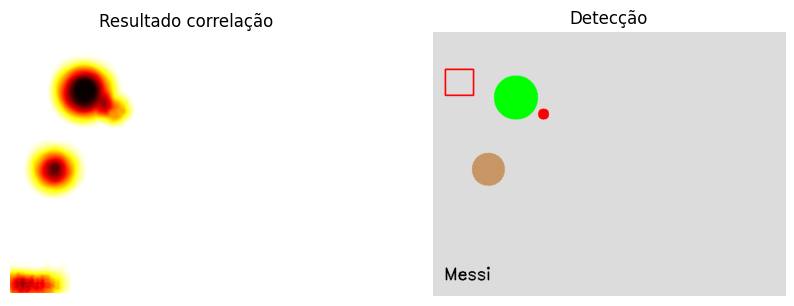

maxLoc (x,y): (22, 69) maxVal: 65437036.0


In [ ]:
# Definir funções de síntese para Messi e bola
def synth_messi():
    img = np.full((480,640,3),220,dtype=np.uint8)
    cv.circle(img,(150,120),40,(0,255,0),-1)
    cv.circle(img,(200,150),10,(0,0,255),-1)
    cv.circle(img,(100,250),30,(100,150,200),-1)
    cv.putText(img,'Messi',(20,450),cv.FONT_HERSHEY_SIMPLEX,1,(0,0,0),2)
    return img

def synth_ball():
    img = np.zeros((20,20),dtype=np.uint8)
    cv.circle(img,(10,10),8,255,-1)
    return img

# Correlação: procurar a bola do messi
messi = load_or_synth('messi5.jpg', synth_messi)
messi_l = cv.cvtColor(messi, cv.COLOR_BGR2GRAY)
# Tentar carregar a bola real primeiro
ball_path = 'messi5_ball.jpg'
ball = cv.imread(ball_path, cv.IMREAD_GRAYSCALE)
if ball is None:
    try:
        ball = cv.imread(cv.samples.findFile(ball_path), cv.IMREAD_GRAYSCALE)
    except:
        pass
if ball is None:
    ball = synth_ball()
res = cv.matchTemplate(messi_l, ball, cv.TM_CCORR)
minVal, maxVal, minLoc, maxLoc = cv.minMaxLoc(res)
top_left = maxLoc
h,w = ball.shape
messi_box = messi.copy()
cv.rectangle(messi_box, top_left, (top_left[0]+w, top_left[1]+h), (0,0,255), 2)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(res, cmap='hot'); plt.title('Resultado correlação'); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(cv.cvtColor(messi_box, cv.COLOR_BGR2RGB)); plt.title('Detecção'); plt.axis('off')
plt.show()
print('maxLoc (x,y):', maxLoc, 'maxVal:', maxVal)

### Aplicação de Filtro: Convolução

A convolução é a forma padrão de aplicação de filtros em processamento de sinais. De forma geral temos (1D):

1. Inverte-se a posição dos elementos do filtro horzontalmente
1. Posiciona-se o ultimo elemento do filtro com o primeiro elemento dos dados
1. Executa-se a multiplicação de cada elemento (tratamento de borda, caso-a-caso)
1. Faz-se a somatória das multiplicações e armazena o resultado no destino
1. Incrementa-se a posição: o primeiro elemento do filtro na segunda posição dos dados
1. Repete-se o processo
    1. A esse processo dá-se o nome de deslizamento (*sliding*), similar à correlação mas com o filtro invertido
1. Ao final o sinal filtrado de saída será maior que o de entrada

> Nota
> * se posicionar o centro do filtro no primeiro elemento, o tam. da saída será igual ao da entrada
> * se posicionar o primeiro elemento do filtro no primeiro elemento do sinal, o tam. da saída será menor que a entrada (como vimos anteriormente no exercício de correlação)

Tanto Numpy quanto OpenCV já possuem funções otimizadas para convolução.

No caso do OpenCV muitas das funções de Blur (filtros passa baixa) estão presentes em funções especializadas.

Tanto OpenCV quanto Numpy possuem funções especializadas para FFT de 1D e 2D (que também é uma convolução).

No caso do Numpy não existe uma função de convolução genérica para 2D. Para executar uma conv. de 2D basta aplicar o método em cada dimenção:

Conv2D = T(Conv(T(Conv(img,kernel)),kernel)), com T sendo a transposição da matriz

> **Nota**: exitem inúmeros filtros que expressam tronsformações simples à complexas, os filtros podem ser organizados em categorias conforme suas propriedades, por exeplo: ortogonais, ortonormais, etc.

#### Exercício Passa-Baixa: média (average)

As operações mais básicas de processamento de sinais é a decomposição de um sinal em baixa e alta frequencia.

Em imagens, assim como em sinais 1D, os filtros passa-baixa (*blur*) serverm para remover ruídos.

No entando, parte da alta-frequencia são os detalhes naturais da imagem (contraste), por isso a tendencia ao se aplicar um *blur* exagerado ou vários em sequência faz a imagem tender a um borrão com uma cor uniforme (nível DC)

1. Vamos abrir ellipses.jpg Grayscale em *ellipses*
1. Vamos aplicar um **filtro de média** simples
    1. Um filtro de média possui todos seus valores 1, ou seja, irá somar os pixels da imagem, depois dividir pela somatória do filtro
1. Crie a imagem final *blur10* e *blur20* usando [cv.blur(src, ksize[, dst[, anchor[, borderType]]])](https://docs.opencv.org/4.x/d4/d86/group__imgproc__filter.html#ga8c45db9afe636703801b0b2e440fce37)
    * ksize=(10,10) e (20, 20)
1. Crie a imagem final *box10* e *box20* usando [cv.boxFilter(src, ddepth, ksize[, dst[, anchor[, normalize[, borderType]]]])](https://docs.opencv.org/4.x/d4/d86/group__imgproc__filter.html#gad533230ebf2d42509547d514f7d3fbc3)
    * ksize=(10,10) e (20, 20)
1. Plot em uma linha: a imagem original, *blur10* e *box10*
1. Plot em outra linha: a imagem original, *blur20* e *box20*

> Nota: blur e é apenas uma versão especializadas de boxFilter. É possível definir um filtro de tamanho arbitrário, bom para manter o aspecto da imagem e evitar ficar desigual por causa de borda.

Perceba que cada elipse tende a uniformizar

ellipses.jpg não encontrado — criando imagem sintética para demonstração.


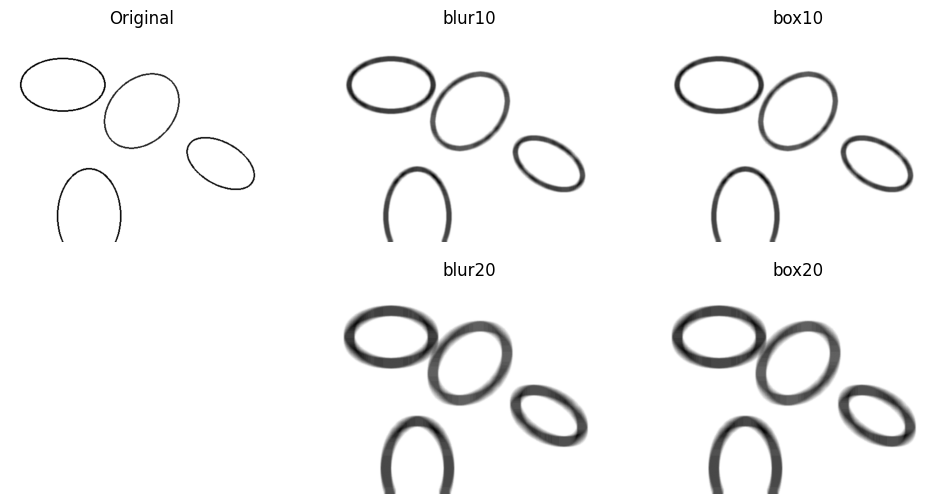

In [21]:
def synth_ellipses():
    img = np.full((400,500),255,dtype=np.uint8)
    cv.ellipse(img,(100,100),(80,50),0,0,360,(100,),2)
    cv.ellipse(img,(250,150),(60,80),45,0,360,(120,),2)
    cv.ellipse(img,(400,250),(70,40),30,0,360,(110,),2)
    cv.ellipse(img,(150,350),(90,60),90,0,360,(105,),2)
    return img

# Filtros passa-baixa (average): ellipses
ellipses = load_or_synth('ellipses.jpg', synth_ellipses)
blur10 = cv.blur(ellipses, (10,10))
blur20 = cv.blur(ellipses, (20,20))
box10 = cv.boxFilter(ellipses, ddepth=-1, ksize=(10,10), normalize=True)
box20 = cv.boxFilter(ellipses, ddepth=-1, ksize=(20,20), normalize=True)
plt.figure(figsize=(12,6))
plt.subplot(2,3,1); plt.imshow(ellipses, cmap='gray'); plt.title('Original'); plt.axis('off')
plt.subplot(2,3,2); plt.imshow(blur10, cmap='gray'); plt.title('blur10'); plt.axis('off')
plt.subplot(2,3,3); plt.imshow(box10, cmap='gray'); plt.title('box10'); plt.axis('off')
plt.subplot(2,3,5); plt.imshow(blur20, cmap='gray'); plt.title('blur20'); plt.axis('off')
plt.subplot(2,3,6); plt.imshow(box20, cmap='gray'); plt.title('box20'); plt.axis('off')
plt.show()

#### Exercício Passa-Baixa: mediana (median)

Uma forma de eliminar ruído "sal-pimenta" (pontos pretos e brancos dispersos aleatóriamente) é utlizar outras formas estatísticas como mediada ou a moda.

* mediana multiplica os pixels por 1, como antes, mas prossegue em achatar (*gravel*) o resultado e ordenar, esolhendo o valor do meio como resultado do pixel
* moda multiplica os pixels por 1, como antes, mas prossegue em fazer o histograma local, escolhendo como cor do pixel o valor com maior presença

Outras formas são: usar o valor de máximo, mínimo, desvio padrão etc.

1. Vamos usar *ellipses*
1. Crie a imagem final *median10* e *median11* usando [cv.medianBlur(src, ksize[, dst])](https://docs.opencv.org/4.x/d4/d86/group__imgproc__filter.html#ga564869aa33e58769b4469101aac458f9)
    * ksize=11 e ksize=21
1. Crie a imagem final *moda10* e *median11* usando **modeBlur**
    * ksize=11 e ksize=21
1. Plot em uma linha a imagem original, *blur*, *box* e *median*

Perceba que a moda tende a preservar mais a borda (contraste)

In [19]:
# OpenCV e Numpy não possui um filtro pra Moda, então aqui esta uma implementação lenta
def modeBlur(img, ksize=3):
    l, c = img.shape
    dst = np.zeros(img.shape, dtype=np.uint8)
    offset = ksize // 2
    for y in range(offset, l - offset):
        for x in range(offset, c - offset):
            sec = img[y-offset:y+offset,x-offset:x+offset].ravel()
            vals, counts = np.unique(sec, return_counts=True)
            modev = vals[np.argmax(counts)]
            dst[y,x] = modev
    return dst

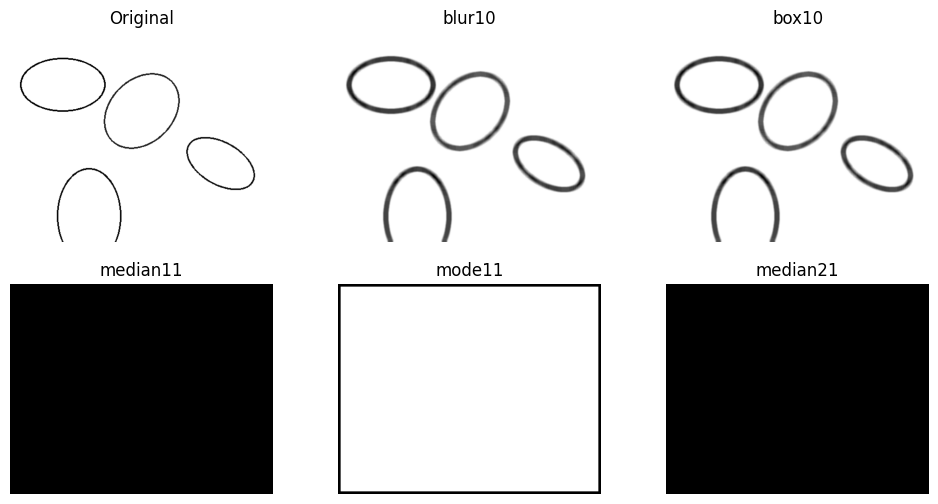

In [22]:
# Filtro mediana e moda (modeBlur já definido acima)
median11 = cv.medianBlur(ellipses, 11)
median21 = cv.medianBlur(ellipses, 21)
mode11 = modeBlur(ellipses, 11)
mode21 = modeBlur(ellipses, 21)
plt.figure(figsize=(12,6))
plt.subplot(2,3,1); plt.imshow(ellipses, cmap='gray'); plt.title('Original'); plt.axis('off')
plt.subplot(2,3,2); plt.imshow(blur10, cmap='gray'); plt.title('blur10'); plt.axis('off')
plt.subplot(2,3,3); plt.imshow(box10, cmap='gray'); plt.title('box10'); plt.axis('off')
plt.subplot(2,3,4); plt.imshow(median11, cmap='gray'); plt.title('median11'); plt.axis('off')
plt.subplot(2,3,5); plt.imshow(mode11, cmap='gray'); plt.title('mode11'); plt.axis('off')
plt.subplot(2,3,6); plt.imshow(median21, cmap='gray'); plt.title('median21'); plt.axis('off')
plt.show()

#### Exercício Passa-alta: Sobel

Os filtros para remover a média (low freq.) e ficar com os detalhes (high freq.), ou seja, mater os contornos/contrastes são muito utilizados em algoritmos de segmentação.

O objetivo da segmentação é colocar um contorno em volta de uma área. Vimos como fazer isso através de processamento de elementos vizinhos, com operadores de desvio (branching). Com imagens coloridas e maiores os processadores não são eficientes para acompanhar a complexidade, o uso de hardware especializado em álgebra, como os DSPs (e hoje em dia as GPUs) torna-se mais interessante.

Na segmentação temos que a área é dada pela baixa freq. e o contorno pela alta freq., sendo uma forma mais algébrica para o mesmo fim e, portanto, mais fácil de ser aplicada em processadores dedicados (DSPs).

Podemos fazer os filtros de alta freq. de duas formas:

* Aplicando um filtro de baixa frequencia na imagem e depois subtraindo ambos: Img<sub>hi-f</sub> = Img - Img<sub>low-f</sub>
* Aplicando um filtro de alta frequencia (também chamado de derivativo de 1<sup>a</sup> ordem) como Sobel

$Sobel \begin{vmatrix}-1&-1&-1\\-1&8&-1\\-1&-1&-1\end{vmatrix}$

> Perceba que o filtro é equilibrado, o módulo da soma dos pesos dos pixels vizinhos é o valor do peso do pixel do centro

1. Vamos carregar blox.jpg Grayscale em *blox*
1. Aplique um filtro de blur simples (box) com o kernel 3x3 (pois nosso Sobel é 3x3), salve o resultado em *blox_low*
1. Subtraia (use a função do Opencv) *blox_low* de *blox*, salve o resultado em *blox_diff* (não se esqueça de multiplicar por 8 para ter a mesma intensidade do nosso filtro de Sobel)
1. Crie nosso filtro de Sobel com np.array
1. Use [cv.filter2D(src, ddepth, kernel[, dst[, anchor[, delta[, borderType]]]])](https://docs.opencv.org/4.x/d4/d86/group__imgproc__filter.html#ga27c049795ce870216ddfb366086b5a04) aplicando nosso filtro na imagem sanvando o resultado em *blox_hi*
1. Plot em uma linha *blox*, *blox_low*, *blox_diff* e *blox_hi*
    * use plt.gcf().set_dpi(...) ou similar para deixar a figura maior

**Destaques**

* Note que *blox_diff* e *blox_low* devem ser exatamente iguais
* Note que a derivada de 1<sup>a</sup> ordem é muito suscetível à ruido
* Note que é mais facil agora criar contornos apenas ajustando a equalização da imagem e/ou usando máscaras

blox.jpg não encontrado — criando imagem sintética para demonstração.


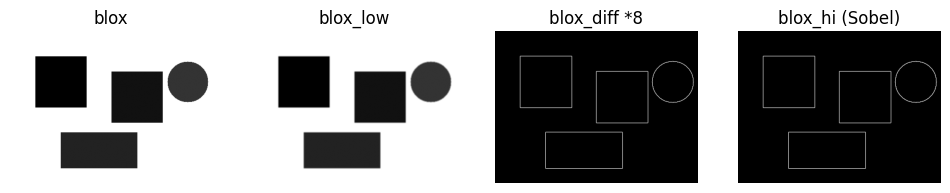

In [23]:
def synth_blox():
    img = np.full((300,400),200,dtype=np.uint8)
    cv.rectangle(img,(50,50),(150,150),50,-1)
    cv.rectangle(img,(200,80),(300,180),60,-1)
    cv.rectangle(img,(100,200),(250,270),70,-1)
    cv.circle(img,(350,100),40,80,-1)
    return img

# Sobel (passa-alta) comparação com subtração
blox = load_or_synth('blox.jpg', synth_blox)
blox_low = cv.blur(blox, (3,3))
blox_diff = cv.subtract(blox, blox_low)
# ajustar intensidade para comparar com o filtro 3x3 proposto (multiplicar por 8)
blox_diff8 = cv.convertScaleAbs(blox_diff, alpha=8, beta=0)
sobel_kernel = np.array([[-1,-1,-1],[-1,8,-1],[-1,-1,-1]], dtype=np.float32)
blox_hi = cv.filter2D(blox, ddepth=-1, kernel=sobel_kernel)
plt.figure(figsize=(12,4))
plt.subplot(1,4,1); plt.imshow(blox, cmap='gray'); plt.title('blox'); plt.axis('off')
plt.subplot(1,4,2); plt.imshow(blox_low, cmap='gray'); plt.title('blox_low'); plt.axis('off')
plt.subplot(1,4,3); plt.imshow(blox_diff8, cmap='gray'); plt.title('blox_diff *8'); plt.axis('off')
plt.subplot(1,4,4); plt.imshow(blox_hi, cmap='gray'); plt.title('blox_hi (Sobel)'); plt.axis('off')
plt.show()